In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)

df = pd.read_excel("(Rosie) COMM5000-Used_Car_Price_Prediction_22-9.xlsm", sheet_name="DATA")

In [2]:
df.shape

(1005000, 20)

In [3]:
df.head(10)

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
0,Toyota,Camry,2001,11.441918,1846.038707,167.674938,Hybrid,Automatic,First,Grey,Chennai,415929.133726,1,1,0,1,4,5,24,1.698003e+05
1,Hyundai,i20,2012,13.691143,1895.698687,164.716733,Petrol,Unknown,First,Grey,Mumbai,91486.948596,0,1,0,1,4,5,13,1.192135e+06
2,Mahindra,Bolero,2008,24.486915,1044.183052,60.082088,Unknown,Automatic,First,Black,Kolkata,77758.956056,1,0,0,1,5,5,17,5.763952e+05
3,BMW,X1,2015,17.498944,1245.275629,148.906768,Unknown,Manual,First,White,Pune,84390.606364,1,1,3,1,4,5,10,7.212595e+05
4,Honda,Civic,2022,23.329621,1025.010433,108.681800,Diesel,Manual,Second,White,Kolkata,156143.722511,1,0,0,1,5,5,3,1.064664e+06
5,Toyota,Camry,2007,22.235951,1243.248074,131.259962,Petrol,Automatic,Second,Unknown,Unknown,69665.573862,0,0,1,1,4,2,18,8.907130e+05
6,Hyundai,i20,2014,14.995179,1732.208539,131.460035,Diesel,Manual,First,Unknown,Chennai,203695.162161,1,0,0,1,4,4,11,5.315523e+05
7,Hyundai,Creta,2001,13.210388,897.497022,83.962559,Petrol,Manual,Second,White,Kolkata,74864.933664,1,0,0,1,5,5,24,1.867063e+05
8,Volkswagen,Taigun,2020,18.592514,1697.942310,143.239253,Diesel,Automatic,Fourth+,Black,Hyderabad,147427.604941,1,1,0,1,4,5,5,2.304395e+06
9,Audi,A4,2009,18.533105,1775.782251,151.328421,Petrol,Manual,Second,Blue,Pune,358485.128165,1,1,1,1,5,7,16,1.787731e+05


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1005000 entries, 0 to 1004999
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Brand             1005000 non-null  str    
 1   Model             1005000 non-null  str    
 2   Year              1005000 non-null  int64  
 3   Mileage_kmpl      1005000 non-null  float64
 4   Engine_CC         1005000 non-null  float64
 5   Horsepower        1005000 non-null  float64
 6   Fuel_Type         1005000 non-null  str    
 7   Transmission      1005000 non-null  str    
 8   Owner_Type        1005000 non-null  str    
 9   Color             1005000 non-null  str    
 10  City              1005000 non-null  str    
 11  Kms_Driven        1005000 non-null  float64
 12  Insurance_Valid   1005000 non-null  int64  
 13  Service_History   1005000 non-null  int64  
 14  Accidents         1005000 non-null  int64  
 15  Tax_Paid          1005000 non-null  int64  
 16  Number_of_D

- 1,005,000 dòng × 20 cột (19 biến + target `Car_Price`). Không có cột ID → giả định 1 dòng = 1 listing.
- `info()`: cả 20 cột đều đủ 1,005,000 non-null → không có ô trống (NaN).
- 7 cột chữ (str), 8 cột số nguyên (int64), 5 cột số thập phân (float64: Mileage_kmpl, Engine_CC, Horsepower, Kms_Driven, Car_Price) → không có cột số bị đọc thành chữ.
- `head(10)`: có 'Unknown' ở Fuel_Type, Transmission, Color, City → dữ liệu thiếu có thể nằm dưới dạng chữ, `isnull()` không bắt được.
- 5 cột float có nhiều số lẻ (vd Kms_Driven 415,929.13; Engine_CC 1,846.04).
- Tên cột không ghi đơn vị (trừ `_kmpl`, `_CC`) → cần tìm mô tả biến.

In [5]:
from openpyxl import load_workbook

wb = load_workbook("(Rosie) COMM5000-Used_Car_Price_Prediction_22-9.xlsm", read_only=True)
print(wb["Dataset"]["B5"].value)
wb.close()

Input variables:
1.Brand: Manufacturer of the vehicle
2.Model: Model name
3.Year: Manufacturing year
4.Mileage_kmpl: Fuel efficiency (km/l)
5.Engine_CC: Engine displacement in cubic centimeters
6.Horsepower: Engine power output
7.Fuel_Type: Fuel category
8.Transmission: Manual or Automatic
9.Owner_Type: Ownership history
10.Color: Vehicle color
11.City: Registration city
12.Kms_Driven: Total distance traveled
13.Insurance_Valid: Insurance status
14.Service_History: Availability of service records
15.Accidents: Number of reported accidents
16.Tax_Paid: Road tax payment status
17.Number_of_Doors: Vehicle door count
18.Seats: Seating capacity
19.Registration_Age: Vehicle age since registration
Output variable: Car_Price: Target variable, in Rupees


**Bảng 1 – Đơn vị và giả định** (theo mô tả ở sheet Dataset)

| Biến | Đơn vị | Nguồn / giả định |
|---|---|---|
| Car_Price | Rupees | "Target variable, in Rupees" |
| Mileage_kmpl | km/l | "Fuel efficiency (km/l)" |
| Engine_CC | cc (cm³) | "Engine displacement in cubic centimeters" |
| Horsepower | không ghi | GIẢ ĐỊNH: hp |
| Kms_Driven | không ghi | GIẢ ĐỊNH: km (theo tên cột) |
| Year | năm | "Manufacturing year" |
| Registration_Age | không ghi | GIẢ ĐỊNH: năm ("Vehicle age since registration") |
| Accidents | số vụ | "Number of reported accidents" |
| Number_of_Doors, Seats | số cửa, số chỗ | "Vehicle door count", "Seating capacity" |
| Insurance_Valid, Service_History, Tax_Paid | 0 / 1 | GIẢ ĐỊNH: 1 = còn hiệu lực / có hồ sơ / đã nộp |
| Brand, Model, Fuel_Type, Transmission, Owner_Type, Color, City | nhãn | — |

- Chỉ Car_Price, Mileage_kmpl, Engine_CC và các biến đếm có đơn vị rõ; Horsepower, Kms_Driven, Registration_Age và ý nghĩa của các biến 0/1 là giả định → ghi nhận là uncertainty.

**To do:** kiểm tra Registration_Age có khớp với Year không.

In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year,1005000.0,2012.00,7.21,2000.00,2006.00,2012.00,2018.00,2024.00
Mileage_kmpl,1005000.0,18.00,4.17,0.00,14.48,17.99,21.52,46.84
Engine_CC,1005000.0,1505.85,408.52,0.00,1150.45,1494.21,1850.09,3917.06
Horsepower,1005000.0,120.53,38.69,0.00,87.31,119.90,153.12,432.61
Kms_Driven,1005000.0,202986.75,175785.54,4206.49,92603.72,153357.04,254255.18,5215535.50
Insurance_Valid,1005000.0,0.85,0.36,0.00,1.00,1.00,1.00,1.00
Service_History,1005000.0,0.75,0.43,0.00,1.00,1.00,1.00,1.00
Accidents,1005000.0,0.30,0.55,0.00,0.00,0.00,1.00,5.00
Tax_Paid,1005000.0,0.90,0.30,0.00,1.00,1.00,1.00,1.00
Number_of_Doors,1005000.0,4.25,0.70,2.00,4.00,4.00,5.00,5.00


**Observations**
- `count` đủ 1,005,000 ở mọi cột số → khớp `info()`.
- `Mileage_kmpl`, `Engine_CC`, `Horsepower` min = 0 → xe có 0 km/l, 0 cc, 0 hp là vô lý. Cần đếm.
- `Kms_Driven`: P75 = 254k nhưng max = 5.22M (≈ 20× P75); mean 203k > median 153k → đuôi phải rất dài.
- `Car_Price`: mean 1.01M > median 671k (cao hơn ~51%) → right-skewed; max 41.4M, min 7,987.
- `Engine_CC` max 3,917 (P75 1,850), `Horsepower` max 433 (P75 153), `Mileage_kmpl` max 46.8 (P75 21.5) → có giá trị nằm xa phần còn lại.
- `Year` 2000–2024 và `Registration_Age` 1–25 có cùng std 7.21 → có thể là 2 cách ghi cùng 1 thông tin.
- Các biến 0/1 và số đếm (Insurance, Service, Tax, Doors, Seats, Accidents) nằm trong khoảng hợp lý.

**To do:** đếm giá trị 0; xem đuôi của Kms_Driven và Car_Price; kiểm tra Year + Registration_Age.

In [7]:
for col in ["Mileage_kmpl", "Engine_CC", "Horsepower", "Kms_Driven", "Car_Price"]:
    print(col, "| = 0:", (df[col] == 0).sum(), "| < 0:", (df[col] < 0).sum())

Mileage_kmpl | = 0: 9 | < 0: 0
Engine_CC | = 0: 13 | < 0: 0
Horsepower | = 0: 19 | < 0: 0
Kms_Driven | = 0: 0 | < 0: 0
Car_Price | = 0: 0 | < 0: 0


In [8]:
zero = (df[["Mileage_kmpl", "Engine_CC", "Horsepower"]] == 0).any(axis=1)
print("Số dòng có ít nhất 1 giá trị 0:", zero.sum())
print(df.loc[zero, "Fuel_Type"].value_counts())
df.loc[zero, ["Brand", "Fuel_Type", "Mileage_kmpl", "Engine_CC", "Horsepower", "Registration_Age", "Car_Price"]].head(10)

Số dòng có ít nhất 1 giá trị 0: 40
Fuel_Type
Petrol      13
Diesel      10
Unknown      6
CNG          5
Electric     3
Hybrid       3
Name: count, dtype: int64


,Brand,Fuel_Type,Mileage_kmpl,Engine_CC,Horsepower,Registration_Age,Car_Price
3764,Honda,Petrol,14.044274,0.000000,75.982394,19,1.611200e+06
37170,Toyota,Petrol,21.441827,0.000000,69.626527,22,5.633685e+05
42263,Mahindra,Unknown,13.653198,0.000000,177.858428,15,6.593415e+06
58442,Skoda,CNG,21.278251,0.000000,146.786811,7,1.654672e+05
79539,Hyundai,Petrol,22.160903,0.000000,0.000000,4,2.801024e+06
110375,Mercedes,Diesel,11.852143,1538.274959,0.000000,19,5.468680e+05
112161,Hyundai,Diesel,24.983207,0.000000,112.597908,14,2.948265e+06
132499,Mercedes,Petrol,24.642341,0.000000,21.543426,1,1.254994e+06
145996,Volkswagen,Diesel,12.141457,0.000000,136.168397,14,1.921211e+05
187767,Hyundai,Unknown,11.845064,1333.860338,0.000000,14,6.594306e+05


- Giá trị 0: Mileage_kmpl 9, Engine_CC 13, Horsepower 19 (41 ô) nằm ở 40 dòng (dòng 79539 có cả Engine_CC và Horsepower = 0). Không có số âm; Kms_Driven và Car_Price không có 0.
- 40 dòng này thuộc đủ loại nhiên liệu (Petrol 13, Diesel 10, Unknown 6, CNG 5, Electric 3, Hybrid 3) → không phải do xe điện không có Engine_CC.
- Các cột khác của những dòng này trông bình thường → lỗi nằm ở từng ô, không phải cả dòng.
- → Khi làm sạch: đổi các ô = 0 thành NaN, giữ dòng.
- Dòng 132499 có Horsepower 21.5, thấp hơn hẳn các dòng khác → có thể còn giá trị rất nhỏ nhưng > 0.

In [9]:
cont_cols = ["Mileage_kmpl", "Engine_CC", "Horsepower", "Kms_Driven", "Car_Price"]
df[cont_cols].quantile([0, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999, 1]).round(2)

,Mileage_kmpl,Engine_CC,Horsepower,Kms_Driven,Car_Price
0.000,0.00,0.00,0.00,4206.49,7987.36
0.001,11.01,862.39,57.90,15115.90,39634.49
0.010,11.02,863.41,58.02,26771.71,81698.27
0.050,11.37,886.17,60.64,44709.31,151559.63
0.500,17.99,1494.21,119.90,153357.04,671405.16
0.950,24.64,2170.26,182.91,525773.17,2983496.99
0.990,24.99,2207.03,186.39,876586.36,5529516.11
0.999,25.01,2208.81,186.56,1549379.54,11152495.40
1.000,46.84,3917.06,432.61,5215535.50,41442180.76


- Mileage_kmpl, Engine_CC, Horsepower: 99.8% giá trị (P0.1 → P99.9) nằm gọn trong 11.0–25.0 km/l, 862–2,209 cc, 57.9–186.6 hp. Từ P0.1 → P1 và P99 → P99.9 gần như không đổi (vd Engine_CC 862.4 → 863.4) → nhiều giá trị dồn sát 2 mép khoảng.
- Ngoài khoảng đó chỉ có vài giá trị lẻ: min = 0, max = 46.84 km/l, 3,917 cc, 432.6 hp → tách xa phần còn lại.
- Kms_Driven và Car_Price thì khác: đuôi phải tăng dần (Kms P99 877k → P99.9 1.55M → max 5.22M; giá P99 5.53M → P99.9 11.15M → max 41.4M), không có mép chặn.

**To do:** vẽ histogram để xem hình dạng 3 biến Mileage / Engine / Horsepower.

In [10]:
import matplotlib.pyplot as plt

# style chung cho biểu đồ
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
})

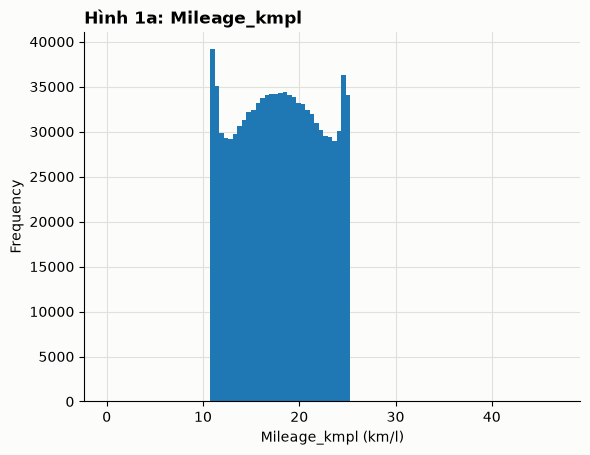

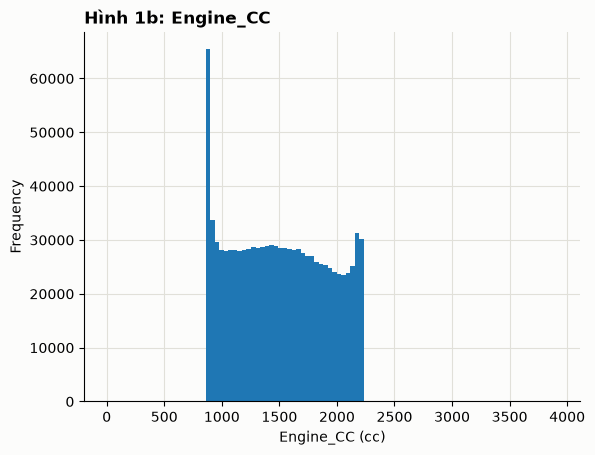

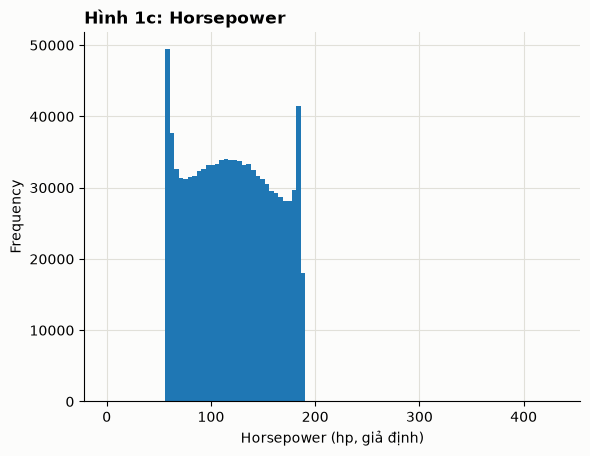

In [11]:
units_plot = {"Mileage_kmpl": "km/l", "Engine_CC": "cc", "Horsepower": "hp, giả định"}
for fig_no, col in zip(["1a", "1b", "1c"], ["Mileage_kmpl", "Engine_CC", "Horsepower"]):
    df[col].plot(kind="hist", bins=100)
    plt.title("Hình " + fig_no + ": " + col)
    plt.xlabel(col + " (" + units_plot[col] + ")")
    plt.show()

**Hình dạng Mileage_kmpl, Engine_CC, Horsepower (Hình 1a–1c)**
- Cả 3 biến gần như phân bố đều trong 1 khoảng cố định (~11–25 km/l, ~860–2,210 cc, ~58–187 hp), có 1 bướu nhẹ ở giữa.
- 2 mép khoảng có cột cao vọt (vd Engine_CC ~65k xe ở cột đầu tiên, so với ~28k ở các cột khác) → giá trị bị dồn về mép, không giống phân phối tự nhiên → nhiều khả năng giá trị đã bị chặn (cap) ở 2 đầu khi ghi nhận → không biết giá trị thật của các xe nằm sát mép.
- Ngoài khoảng gần như không thấy cột nào → số giá trị nằm ngoài rất ít.

**To do:** xem các giá trị nằm ngoài khoảng chính cách xa bao nhiêu.

In [12]:
for col in ["Mileage_kmpl", "Engine_CC", "Horsepower"]:
    s = df[col].sort_values()
    print(col)
    print("   10 nhỏ nhất:", s.head(10).round(1).tolist())
    print("   10 lớn nhất:", s.tail(10).round(1).tolist())

Mileage_kmpl
   10 nhỏ nhất: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1]
   10 lớn nhất: [32.7, 34.3, 34.4, 35.3, 35.4, 36.1, 37.4, 39.7, 39.8, 46.8]
Engine_CC
   10 nhỏ nhất: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
   10 lớn nhất: [3442.7, 3616.5, 3659.2, 3720.1, 3736.1, 3754.2, 3782.3, 3801.9, 3854.5, 3917.1]
Horsepower
   10 nhỏ nhất: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
   10 lớn nhất: [291.3, 292.4, 310.5, 317.7, 318.2, 319.7, 333.2, 353.0, 365.1, 432.6]


- Đầu nhỏ: toàn là các giá trị 0 đã đếm ở trên (và 1 giá trị Mileage 0.1).
- Đầu lớn: giá trị trải dần tới max (vd Engine_CC 3,443 → 3,917 cc; Horsepower 291 → 433 hp), không dồn vào 1 mức → vượt mép trên của khoảng chính tới ~1.8×.

**To do:** đếm số giá trị nằm ngoài khoảng chính (mép lấy theo Hình 1 và bảng phân vị).

In [13]:
main_range = {"Mileage_kmpl": (11, 25.1), "Engine_CC": (860, 2210), "Horsepower": (57, 187)}
for col, (lo, hi) in main_range.items():
    below = (df[col] < lo).sum()
    above = (df[col] > hi).sum()
    print(col, "| khoảng chính:", lo, "-", hi, "| thấp hơn:", below, "| cao hơn:", above,
          "| % ngoài khoảng:", round((below + above) / len(df) * 100, 3))

Mileage_kmpl | khoảng chính: 11 - 25.1 | thấp hơn: 71 | cao hơn: 48 | % ngoài khoảng: 0.012
Engine_CC | khoảng chính: 860 - 2210 | thấp hơn: 82 | cao hơn: 186 | % ngoài khoảng: 0.027
Horsepower | khoảng chính: 57 - 187 | thấp hơn: 71 | cao hơn: 102 | % ngoài khoảng: 0.017


In [14]:
for col, (lo, hi) in main_range.items():
    pos = df.loc[df[col] > 0, col]
    print(col, "| số giá trị dương < mép dưới", lo, ":", (pos < lo).sum())
    print("   10 giá trị dương nhỏ nhất:", pos.nsmallest(10).round(2).tolist())

Mileage_kmpl | số giá trị dương < mép dưới 11 : 62
   10 giá trị dương nhỏ nhất: [0.07, 0.5, 1.14, 2.21, 3.7, 3.86, 4.13, 4.33, 4.39, 4.41]
Engine_CC | số giá trị dương < mép dưới 860 : 69
   10 giá trị dương nhỏ nhất: [10.77, 80.8, 84.54, 110.66, 144.79, 146.43, 166.28, 181.61, 236.49, 245.87]
Horsepower | số giá trị dương < mép dưới 57 : 52
   10 giá trị dương nhỏ nhất: [6.62, 9.15, 9.31, 9.37, 10.19, 13.21, 14.6, 16.41, 16.53, 16.67]


- Ngoài khoảng chính (tính cả các giá trị 0): Mileage_kmpl 119 (0.012%), Engine_CC 268 (0.027%), Horsepower 173 (0.017%) → rất ít.
- Bỏ các giá trị 0 ra, vẫn còn giá trị dương nằm dưới mép dưới: Mileage 62, Engine_CC 69, Horsepower 52. Nhỏ nhất là 0.07 / 0.5 / 1.14 km/l; 10.77 / 80.8 / 84.5 cc; 6.62 / 9.15 / 9.31 hp → trải rải rác từ gần 0 tới mép dưới, không dồn vào 1 mức, và cách xa P0.1 (11 km/l, 862 cc, 57.9 hp).
- Đây là bất thường thấy ngay trong phân phối (tách khỏi 99.8% giá trị), nhưng dữ liệu không cho thấy ranh giới rõ giữa "sai" và "hiếm".
- → Giá trị 0 đổi thành NaN (không thể có). Các giá trị dương rất nhỏ và các giá trị lớn ngoài khoảng: giữ, ghi nhận là outlier; kiểm tra độ nhạy ở Bảng 12.

In [15]:
(df["Year"] + df["Registration_Age"]).value_counts()

2025    1005000
Name: count, dtype: int64

- Year + Registration_Age = 2025 ở 100% dòng → 2025 là mốc số học dùng để tính Registration_Age; output không cho biết đây là năm thu thập dữ liệu hay năm đăng tin.
- 2 biến chứa cùng 1 thông tin → chỉ dùng Registration_Age trong phân tích.

Kms_Driven > 1,000,000: 6106
Tỉ lệ xe <= 2 triệu km: 99.97 %


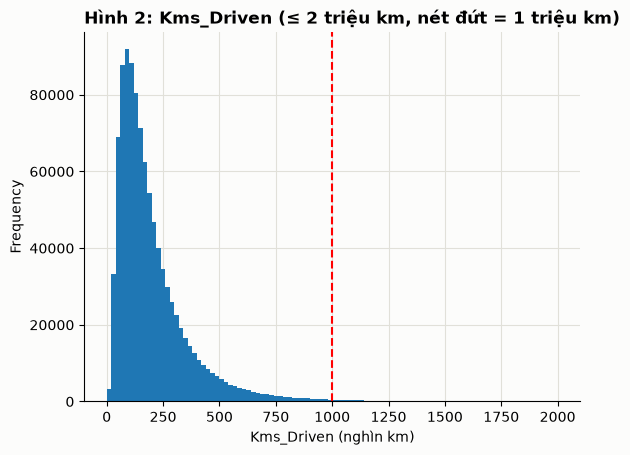

In [16]:
print("Kms_Driven > 1,000,000:", (df["Kms_Driven"] > 1_000_000).sum())
print("Tỉ lệ xe <= 2 triệu km:", round((df["Kms_Driven"] <= 2_000_000).mean() * 100, 2), "%")

(df["Kms_Driven"] / 1000).plot(kind="hist", bins=100, range=(0, 2000))
plt.axvline(1000, color="red", linestyle="--")
plt.title("Hình 2: Kms_Driven (≤ 2 triệu km, nét đứt = 1 triệu km)")
plt.xlabel("Kms_Driven (nghìn km)")
plt.show()

**Kms_Driven (Hình 2)**
- Lệch phải: đỉnh ở khoảng 80–100k km, sau đó giảm dần; 99.97% xe ≤ 2 triệu km, max 5.22M km.
- Kms > 1,000,000 (ví dụ "implausible" trong Guide): 6,106 xe (0.61%).
- Trên Hình 2, phân phối giảm liền mạch qua mốc 1 triệu km, không có nhóm tách riêng → chỉ nhìn phân phối thì chưa thấy mốc 1M là ranh giới giữa dữ liệu đúng và sai.

**To do:** xem Kms có tăng theo tuổi xe không, và nhóm > 1M có gì khác phần còn lại.

In [17]:
print("Correlation Registration_Age vs Kms_Driven:", round(df["Registration_Age"].corr(df["Kms_Driven"]), 3))
df.groupby("Registration_Age")["Kms_Driven"].median().round().head(25)

Correlation Registration_Age vs Kms_Driven: 0.0


Registration_Age
1     152578.0
2     153401.0
3     152402.0
4     154237.0
5     153480.0
6     154128.0
7     152362.0
8     153848.0
9     153282.0
10    153818.0
11    154087.0
12    153084.0
13    153201.0
14    152498.0
15    154052.0
16    153024.0
17    152502.0
18    153303.0
19    152676.0
20    152985.0
21    153683.0
22    154254.0
23    153391.0
24    154427.0
25    153689.0
Name: Kms_Driven, dtype: float64

- Correlation Registration_Age – Kms_Driven = 0.0; median Kms ở mọi tuổi xe đều ~152k–154k km (xe 1 năm ~ xe 25 năm).
- Kms_Driven là tổng quãng đường đã chạy → lẽ ra phải tích luỹ theo thời gian (GIẢ ĐỊNH, logic thông thường). Trong file này Kms không tăng theo tuổi xe → Kms và tuổi xe không nhất quán với nhau → ghi vào limitation.
- Hệ quả: không dùng được "km/năm" để tìm dòng vô lý (vì xe 1 năm cũng có ~150k km như xe cũ).

In [18]:
kms_1m = df["Kms_Driven"] > 1_000_000
df.groupby(kms_1m)[["Registration_Age", "Car_Price"]].median().round()

,Registration_Age,Car_Price
Kms_Driven,,
False,13.0,672242.0
True,13.0,545952.0


- Nhóm Kms > 1M: median tuổi 13 năm (bằng nhóm còn lại), median giá ~546k, thấp hơn nhóm còn lại (~672k).
- → Nhóm này không khác thường ở tuổi xe hay giá (không giống lỗi nhập liệu kiểu "chạy nhiều mà giá cao bất thường"). Guide coi > 1M km là implausible nhưng dữ liệu không có ranh giới rõ ở 1M → cách xử lý quyết định ở phần làm sạch, kèm kiểm tra độ nhạy.

In [19]:
s = df["Car_Price"].sort_values()
print("10 giá nhỏ nhất:", s.head(10).round().tolist())
print("10 giá lớn nhất:", s.tail(10).round().tolist())
print("Số mức giá khác nhau:", df["Car_Price"].nunique())
print("Mức giá lặp nhiều nhất:", df["Car_Price"].value_counts().iloc[0], "lần")

10 giá nhỏ nhất: [7987.0, 8541.0, 11197.0, 11386.0, 11388.0, 11966.0, 12789.0, 13441.0, 13566.0, 14229.0]
10 giá lớn nhất: [29542210.0, 29621039.0, 31543914.0, 31551469.0, 31606205.0, 32435615.0, 33847554.0, 36989173.0, 37227010.0, 41442181.0]
Số mức giá khác nhau: 1005000
Mức giá lặp nhiều nhất: 1 lần


- Car_Price: 1,005,000 mức giá khác nhau, không mức nào lặp lại → không có giá sàn / giá trần.
- 2 đầu tăng dần, không có bước nhảy lớn (nhỏ nhất 7,987 → 14,229; lớn nhất 29.5M → 41.4M) → đuôi phải dài nhưng liền mạch, chưa có căn cứ coi là lỗi. Xem lại ở phần outlier.

**Tiếp theo:** các cột số đã xem xong → chuyển sang các cột chữ (`head()` đã thấy 'Unknown').

In [20]:
for col in ["Brand", "Model", "Fuel_Type", "Transmission", "Owner_Type", "Color", "City"]:
    print(df[col].value_counts())
    print("-" * 30)

Brand
BMW             76773
Skoda           76762
Hyundai         76750
Ford            76694
Toyota          76630
Audi            76573
Honda           76542
Kia             76524
Mercedes        76492
Volkswagen      76441
Mahindra        76308
Tata            76297
Nissan          76174
 Mercedes         813
 Nissan           792
 Skoda            789
 BMW              788
 Mahindra         785
 Tata             778
 Honda            770
 Kia              769
 Hyundai          767
 Toyota           767
 Ford             745
 Volkswagen       744
 Audi             733
Name: count, dtype: int64
------------------------------
Model
Verna        26046
Octavia      26008
Camry        25976
3 Series     25975
Amaze        25950
Figo         25942
Kushaq       25939
EcoSport     25922
A4           25919
i20          25880
E-Class      25871
Magnite      25850
Carens       25819
Virtus       25809
Q3           25807
X3           25806
Bolero       25798
Yaris        25789
Harrier      2578

Fuel_Type
Petrol      407577
Diesel      272056
CNG          90628
Unknown      78733
Electric     72513
Hybrid       63370
hybridd       3423
 Diesel       3390
diesel        3373
petrol        3351
PETROL        3317
electrik      3269
Name: count, dtype: int64
------------------------------
Transmission
Manual       600630
Automatic    323985
Unknown       80385
Name: count, dtype: int64
------------------------------
Owner_Type
First      602365
Second     251715
Third      100653
Fourth+     50267
Name: count, dtype: int64
------------------------------
Color
Red        132535
Blue       132306
Black      132298
White      132027
Brown      131985
Grey       131932
Silver     131498
Unknown     80419
Name: count, dtype: int64
------------------------------
City
Delhi        115999
Hyderabad    115854
Mumbai       115777
Pune         115588
Ahmedabad    115480
Bangalore    115471
Kolkata      115405
Chennai      114996
Unknown       80430
Name: count, dtype: int64
-----------------

**Observations**
- `Brand`: 26 nhãn cho 13 hãng. Mỗi hãng có 1 biến thể có khoảng trắng (vd `' BMW '`, 733–813 dòng mỗi biến thể) → phải strip trước khi tạo segment Luxury.
- `Model`: 39 model, mỗi model ~25.5–26k dòng, không thấy lỗi nhãn.
- `Fuel_Type`: 12 nhãn. Ngoài 6 nhãn chính có lỗi hoa-thường (`petrol`, `PETROL`), khoảng trắng (`' Diesel'`), chính tả (`hybridd`, `electrik`), mỗi biến thể ~3.3–3.4k dòng.
- `Unknown` ở Fuel_Type (78,733), Transmission (80,385), Color (80,419), City (80,430) → ~8% mỗi cột, là missing dạng chữ.
- `Owner_Type`: 4 nhãn, không lỗi.
- Số dòng gần như bằng nhau giữa các Brand, Model, Color, City → mẫu được lấy chia đều theo các nhóm, không theo tỉ lệ tự nhiên → ghi vào limitation.

**To do:** đếm số nhãn sau khi strip + lower; số xe Luxury bị ảnh hưởng; kiểm tra mỗi Model có thuộc đúng 1 Brand không.

In [21]:
for col in ["Brand", "Model", "Fuel_Type", "Transmission", "Owner_Type", "Color", "City"]:
    print(col, ":", df[col].nunique(), "->", df[col].str.strip().str.lower().nunique())

lux = ["Audi", "BMW", "Mercedes"]
print("Luxury (nhãn gốc):", df["Brand"].isin(lux).sum())
print("Luxury (sau strip):", df["Brand"].str.strip().isin(lux).sum())
print("Model thuộc > 1 Brand:", (df.groupby("Model")["Brand"].agg(lambda b: b.str.strip().nunique()) > 1).sum())

Brand : 26 -> 13


Model : 39 -> 39
Fuel_Type : 12 -> 8


Transmission : 3 -> 3


Owner_Type : 4 -> 4
Color : 8 -> 8


City : 9 -> 9
Luxury (nhãn gốc): 229838


Luxury (sau strip): 232172
Model thuộc > 1 Brand: 0


- Số nhãn trước → sau `strip().lower()`: Brand 26 → 13, Fuel_Type 12 → 8; các cột khác không đổi → chỉ Brand và Fuel_Type có lỗi khoảng trắng / hoa-thường.
- Fuel_Type vẫn còn 8 nhãn (thay vì 6) vì 2 lỗi chính tả `hybridd`, `electrik` → phải map bằng tay.
- Luxury: 229,838 (nhãn gốc) vs 232,172 (sau strip) → 2,334 xe Luxury bị xếp nhầm vào Non-luxury nếu không strip.
- Mỗi Model chỉ thuộc 1 Brand → Brand – Model nhất quán.

**To do:** 'Unknown' – bao nhiêu dòng, có tập trung ở nhóm nào hay liên quan tới giá không.

In [22]:
unknown = (df[["Fuel_Type", "Transmission", "Color", "City"]] == "Unknown").any(axis=1)
print("Dòng có ít nhất 1 'Unknown':", unknown.sum(), "|", round(unknown.mean() * 100, 1), "%")
print("Median giá - dòng có Unknown:", round(df.loc[unknown, "Car_Price"].median()))
print("Median giá - dòng không Unknown:", round(df.loc[~unknown, "Car_Price"].median()))
(unknown.groupby(df["Brand"].str.strip()).mean() * 100).round(1)

Dòng có ít nhất 1 'Unknown': 283648 | 28.2 %
Median giá - dòng có Unknown: 670704
Median giá - dòng không Unknown: 671618


Brand
Audi          28.3
BMW           28.3
Ford          28.0
Honda         28.3
Hyundai       28.2
Kia           27.9
Mahindra      28.3
Mercedes      28.6
Nissan        28.0
Skoda         28.4
Tata          28.0
Toyota        28.5
Volkswagen    28.2
dtype: float64

- 283,648 dòng (28.2%) có ít nhất 1 'Unknown' → xoá thì mất gần 1/3 dữ liệu.
- % dòng có 'Unknown' theo Brand: 27.9–28.6% → không tập trung ở hãng nào.
- Median giá: có Unknown 670,704 vs không 671,618 → không thấy khác biệt lớn về median giá khi so sánh gộp; cơ chế thiếu nhãn chưa rõ.
- → Giữ lại, coi 'Unknown' là 1 nhóm riêng (xoá sẽ mất 28.2% dòng).

**Tiếp theo:** Guide nhắc tới "duplicated records" → kiểm tra dòng trùng.

In [23]:
print("Dòng trùng hoàn toàn:", df.duplicated().sum())

Dòng trùng hoàn toàn: 0


- 0 dòng trùng hoàn toàn. Thực ra không thể có: Car_Price có 1,005,000 giá trị khác nhau (bước trên) → 2 dòng bất kỳ luôn khác nhau ở giá, kể cả sau khi chuẩn hoá nhãn.
- Guide nói dữ liệu có "a small number of duplicated records" → có thể cùng 1 xe được đăng lại nhưng các cột số (km, giá…) được ghi khác đi.

**To do:** kiểm tra trùng trên các cột không phải số thập phân (bỏ 5 cột float).

In [24]:
float_cols = ["Mileage_kmpl", "Engine_CC", "Horsepower", "Kms_Driven", "Car_Price"]
other_cols = [c for c in df.columns if c not in float_cols]
print("Số cột dùng để so:", len(other_cols))
print("Dòng trùng ở các cột này:", df.duplicated(subset=other_cols).sum())

dups = df[df.duplicated(subset=other_cols, keep=False)]
dups.sort_values(other_cols).head(6)

Số cột dùng để so: 15
Dòng trùng ở các cột này: 28329


,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
5206,Audi,A4,2022,24.250268,2055.798113,166.507535,Diesel,Manual,First,Silver,Pune,53942.795073,1,1,0,1,4,4,3,1.256368e+06
346515,Audi,A4,2022,17.639448,1606.650557,114.292927,Diesel,Manual,First,Silver,Pune,303993.511034,1,1,0,1,4,4,3,1.291581e+06
91187,Audi,Q3,2008,24.122651,1186.372371,77.045427,Diesel,Automatic,First,Silver,Hyderabad,46856.942597,1,1,1,1,4,5,17,2.618849e+05
165808,Audi,Q3,2008,12.213664,1753.959041,158.355633,Diesel,Automatic,First,Silver,Hyderabad,232699.366314,1,1,1,1,4,5,17,9.078115e+05
39509,Audi,Q3,2014,14.858285,1009.308819,79.400073,Petrol,Unknown,Second,Grey,Bangalore,367078.880068,1,0,0,1,4,5,11,7.724088e+05
53426,Audi,Q3,2014,12.965093,1693.496825,181.329324,Petrol,Unknown,Second,Grey,Bangalore,193415.776496,1,0,0,1,4,5,11,7.661139e+05


- Trùng ở 15 cột không phải số thập phân: 28,329 dòng (2.8%).
- Ví dụ: 2 xe Audi A4 2022 giống hệt nhau ở 15 cột này nhưng Kms_Driven 53,943 vs 303,994 km, Engine_CC 2,056 vs 1,607 cc, giá 1.26M vs 1.29M.
- Không phân biệt được đây là cùng 1 listing bị lặp (đăng lại với số liệu khác) hay 2 xe khác nhau tình cờ trùng. 15 cột này phần lớn chỉ có vài giá trị (hãng, màu, city, 0/1…) nên với 1 triệu dòng, trùng tình cờ là có thể.
- → Giữ lại, ghi vào độ không chắc chắn; kiểm tra ảnh hưởng nếu xoá ở cuối notebook.

In [25]:
print("Dòng có Brand chứa khoảng trắng thừa:", (df["Brand"] != df["Brand"].str.strip()).sum())

Dòng có Brand chứa khoảng trắng thừa: 10040


**Bảng 2 – Cách xử lý dữ liệu**

| # | Vấn đề | Số lượng | Cách xử lý | Lý do |
|---|---|---|---|---|
| 1 | Brand có khoảng trắng thừa | 10,040 dòng (13 biến thể) | Strip trước khi tạo Segment | Không strip → 2,334 xe Luxury bị xếp nhầm Non-luxury |
| 2 | Fuel_Type không thống nhất | 12 nhãn → 6 | Chuẩn hoá (strip, lower, sửa `hybridd`, `electrik`) | Cùng 1 loại bị đếm thành nhiều nhóm |
| 3 | 'Unknown' | 283,648 dòng (28.2%) | Giữ, coi là 1 nhóm riêng | Tỉ lệ gần nhau giữa các Brand; so sánh gộp không thấy khác biệt lớn về median giá; cơ chế thiếu nhãn chưa rõ; xoá mất 28.2% dòng |
| 4 | Missing (NaN) | 0 | Không cần xử lý | Không có ô trống; dữ liệu thiếu nằm ở dạng 'Unknown' (dòng 3) |
| 5 | Dòng trùng | 0 trùng hoàn toàn; 28,329 trùng ở 15 cột | Giữ | Không chắc là cùng 1 listing |
| 6 | Mileage_kmpl / Engine_CC / Horsepower = 0 | 41 ô, 40 dòng | Đổi thành NaN | Giá trị vô lý; các cột khác của dòng vẫn dùng được |
| 7 | Giá trị ngoài khoảng chính của Mileage / Engine / HP (khác 0), gồm cả giá trị dương rất nhỏ (vd 0.07 km/l, 10.77 cc, 6.62 hp) | Mileage 110, Engine_CC 255, Horsepower 154 (≤ 0.03% mỗi cột) | Giữ, ghi nhận là outlier | Tách khỏi 99.8% giá trị nhưng không có ranh giới rõ giữa sai và hiếm; Bảng 12: đổi thành NaN gần như không đổi mean / median / Spearman |
| 8 | Kms_Driven > 1,000,000 | 6,106 dòng (0.61%) | Loại khỏi phân tích | Guide coi là implausible; dữ liệu không có ranh giới rõ ở 1M → kiểm tra độ nhạy ở cuối |
| 9 | Year trùng thông tin với Registration_Age | 100% dòng | Chỉ dùng Registration_Age | Year + Age = 2025 ở mọi dòng |
| 10 | Car_Price vượt ngưỡng outlier IQR (Q3 + 1.5 IQR ≈ 2.55M, xem Hình 5) | 70,605 dòng (7.1%, sau làm sạch) | Giữ; báo cáo median | Đuôi nối liền, không tập trung ở segment nào; chưa có bằng chứng đủ để coi là lỗi. Bảng 11: bỏ đi làm median giảm ~7.7% |

**Nguyên tắc:** lỗi ở 1 ô thì sửa ô đó; chỉ loại dòng theo quy tắc đã nêu (Kms > 1M). Làm trên bản copy `df_clean`, giữ nguyên `df`.

In [26]:
df_clean = df.copy()
print("Ban đầu:", len(df_clean))

Ban đầu: 1005000


In [27]:
# 1. Xoá khoảng trắng ở các cột chữ
for col in ["Brand", "Model", "Fuel_Type", "Transmission", "Owner_Type", "Color", "City"]:
    df_clean[col] = df_clean[col].str.strip()
print("Số nhãn Brand:", df_clean["Brand"].nunique())

Số nhãn Brand: 13


In [28]:
# 2. Chuẩn hoá Fuel_Type
df_clean["Fuel_Type"] = df_clean["Fuel_Type"].str.lower().replace({
    "petrol": "Petrol", "diesel": "Diesel", "cng": "CNG",
    "electric": "Electric", "electrik": "Electric",
    "hybrid": "Hybrid", "hybridd": "Hybrid",
    "unknown": "Unknown",
})
df_clean["Fuel_Type"].value_counts()

Fuel_Type
Petrol      414245
Diesel      278819
CNG          90628
Unknown      78733
Electric     75782
Hybrid       66793
Name: count, dtype: int64

In [29]:
# 3. Tạo Segment từ Brand đã strip
df_clean["Segment"] = df_clean["Brand"].isin(["Audi", "BMW", "Mercedes"]).map({True: "Luxury", False: "Non-luxury"})
df_clean["Segment"].value_counts()

Segment
Non-luxury    772828
Luxury        232172
Name: count, dtype: int64

In [30]:
# 4. Giá trị 0 ở Mileage_kmpl, Engine_CC, Horsepower → NaN
for col in ["Mileage_kmpl", "Engine_CC", "Horsepower"]:
    df_clean.loc[df_clean[col] == 0, col] = np.nan
print("Số ô đổi thành NaN:", df_clean[["Mileage_kmpl", "Engine_CC", "Horsepower"]].isnull().sum().sum())

Số ô đổi thành NaN: 41


In [31]:
# 5. Loại Kms_Driven > 1,000,000
df_clean = df_clean[df_clean["Kms_Driven"] <= 1_000_000]
print("Sau khi loại Kms > 1M:", len(df_clean))

Sau khi loại Kms > 1M: 998894


In [32]:
# Kiểm tra lại sau khi làm sạch
print("Số nhãn Brand:", df_clean["Brand"].nunique())
print("Số nhãn Fuel_Type:", df_clean["Fuel_Type"].nunique())
print("Giá trị 0 (Mileage/Engine/HP):", (df_clean[["Mileage_kmpl", "Engine_CC", "Horsepower"]] == 0).sum().sum())
print("Kms_Driven lớn nhất:", df_clean["Kms_Driven"].max())
print("Sau làm sạch:", len(df_clean), "dòng |", round(len(df_clean) / len(df) * 100, 2), "% dữ liệu gốc")
df_clean["Segment"].value_counts()

Số nhãn Brand: 13
Số nhãn Fuel_Type: 6
Giá trị 0 (Mileage/Engine/HP): 0
Kms_Driven lớn nhất: 999969.1407928446
Sau làm sạch: 998894 dòng | 99.39 % dữ liệu gốc


Segment
Non-luxury    768145
Luxury        230749
Name: count, dtype: int64

**Làm sạch (theo Bảng 2)**
- Ban đầu: 1,005,000 dòng.
- Strip khoảng trắng các cột chữ → Brand còn 13 nhãn.
- Fuel_Type chuẩn hoá về 6 nhãn: Petrol 414,245 · Diesel 278,819 · CNG 90,628 · Unknown 78,733 · Electric 75,782 · Hybrid 66,793.
- Segment (trước khi loại Kms): Luxury 232,172, Non-luxury 772,828.
- Giá trị 0 → NaN: 41 ô.
- Loại Kms > 1,000,000: 6,106 dòng → còn 998,894 dòng (99.39%).
- 'Unknown' và dòng trùng ở 15 cột giữ nguyên.
- Kiểm tra lại: Brand 13 nhãn, Fuel_Type 6 nhãn, 0 giá trị 0, Kms max 999,969 → các bước đã áp dụng đúng.
- Sau làm sạch: Luxury 230,749 (23.1%), Non-luxury 768,145.

In [33]:
num_cols = ["Car_Price", "Registration_Age", "Kms_Driven", "Engine_CC", "Horsepower", "Mileage_kmpl", "Accidents"]
units = {"Car_Price": "Car_Price (Rupees)", "Registration_Age": "Registration_Age (năm)",
         "Kms_Driven": "Kms_Driven (km)", "Engine_CC": "Engine_CC (cc)", "Horsepower": "Horsepower (hp*)",
         "Mileage_kmpl": "Mileage_kmpl (km/l)", "Accidents": "Accidents (số vụ)"}
discrete = ["Registration_Age", "Accidents"]   # chỉ biến rời rạc mới có mode ý nghĩa

def summary(data):
    mode = data[num_cols].mode().iloc[0]
    mode[~mode.index.isin(discrete)] = np.nan   # biến liên tục: giá trị gần như không lặp lại → không có mode
    return pd.DataFrame({
        "Mean":   data[num_cols].mean(),
        "Mode":   mode,
        "Median": data[num_cols].median(),
        "SD":     data[num_cols].std(),
        "Min":    data[num_cols].min(),
        "Max":    data[num_cols].max(),
    }).round(2).rename(index=units)

In [34]:
print("Bảng 3a – Thống kê mô tả: Toàn bộ")
summary(df_clean)

Bảng 3a – Thống kê mô tả: Toàn bộ


,Mean,Mode,Median,SD,Min,Max
Car_Price (Rupees),1013854.17,NaN,672242.31,1140411.04,7987.36,41442180.76
Registration_Age (năm),13.00,19.0,13.00,7.21,1.00,25.00
Kms_Driven (km),196242.51,NaN,152504.22,150995.95,4206.49,999969.14
Engine_CC (cc),1505.85,NaN,1494.24,408.49,10.77,3917.06
Horsepower (hp*),120.53,NaN,119.90,38.69,6.62,432.61
Mileage_kmpl (km/l),18.00,NaN,17.99,4.17,0.07,46.84
Accidents (số vụ),0.30,0.0,0.00,0.55,0.00,5.00


In [35]:
print("Bảng 3b – Thống kê mô tả: Luxury")
summary(df_clean[df_clean["Segment"] == "Luxury"])

Bảng 3b – Thống kê mô tả: Luxury


,Mean,Mode,Median,SD,Min,Max
Car_Price (Rupees),1014181.86,NaN,670974.38,1140297.21,13441.37,41442180.76
Registration_Age (năm),13.02,18.0,13.00,7.21,1.00,25.00
Kms_Driven (km),196269.55,NaN,152082.39,151213.01,6926.95,998994.38
Engine_CC (cc),1505.89,NaN,1494.55,408.81,10.77,3854.46
Horsepower (hp*),120.55,NaN,119.99,38.69,16.67,352.99
Mileage_kmpl (km/l),18.00,NaN,17.98,4.17,3.70,29.64
Accidents (số vụ),0.30,0.0,0.00,0.55,0.00,5.00


In [36]:
print("Bảng 3c – Thống kê mô tả: Non-luxury")
summary(df_clean[df_clean["Segment"] == "Non-luxury"])

Bảng 3c – Thống kê mô tả: Non-luxury


,Mean,Mode,Median,SD,Min,Max
Car_Price (Rupees),1013755.74,NaN,672576.45,1140445.95,7987.36,37227010.43
Registration_Age (năm),13.00,19.0,13.00,7.21,1.00,25.00
Kms_Driven (km),196234.39,NaN,152608.48,150930.78,4206.49,999969.14
Engine_CC (cc),1505.84,NaN,1494.14,408.39,84.54,3917.06
Horsepower (hp*),120.52,NaN,119.87,38.69,6.62,432.61
Mileage_kmpl (km/l),18.00,NaN,17.99,4.17,0.07,46.84
Accidents (số vụ),0.30,0.0,0.00,0.55,0.00,5.00


In [37]:
cat_cols = ["Fuel_Type", "Transmission", "Owner_Type", "Color", "City",
            "Insurance_Valid", "Service_History", "Tax_Paid", "Seats", "Number_of_Doors"]
rows = []
for col in cat_cols:
    t = pd.crosstab(df_clean[col], df_clean["Segment"], normalize="columns").mul(100)
    t.insert(0, "Toàn bộ", df_clean[col].value_counts(normalize=True).mul(100))
    t.index = [col + " = " + str(v) for v in t.index]
    rows.append(t)

print("Bảng 3d – Tỉ lệ (%) các biến phân loại và 0/1: Toàn bộ, Luxury, Non-luxury")
pd.set_option("display.max_rows", 100)
pd.concat(rows).round(1)

Bảng 3d – Tỉ lệ (%) các biến phân loại và 0/1: Toàn bộ, Luxury, Non-luxury


Segment,Toàn bộ,Luxury,Non-luxury
Fuel_Type = CNG,9.0,9.0,9.0
Fuel_Type = Diesel,27.7,27.8,27.7
Fuel_Type = Electric,7.5,7.5,7.6
Fuel_Type = Hybrid,6.6,6.7,6.6
Fuel_Type = Petrol,41.2,41.2,41.2
Fuel_Type = Unknown,7.8,7.8,7.8
Transmission = Automatic,32.2,32.2,32.2
Transmission = Manual,59.8,59.7,59.8
Transmission = Unknown,8.0,8.1,8.0
Owner_Type = First,59.9,59.9,59.9


**Thống kê theo segment (Bảng 3a–3d)**
- Car_Price gần như giống hệt giữa 2 segment: median Luxury 670,974 vs Non-luxury 672,576; mean ~1.014M và SD ~1.140M ở cả 2 → khác với giả định ban đầu của đề (Luxury đắt hơn) → cần kiểm tra thêm bằng hình và theo Brand.
- Car_Price: mean > median ở cả 3 bảng (~1.51 lần) → right-skewed.
- Các biến còn lại (tuổi xe, km, Engine_CC, Horsepower, Mileage, Accidents) cũng gần như giống hệt giữa 2 segment.
- Mode chỉ tính cho biến rời rạc (Registration_Age, Accidents). Biến liên tục gần như không có giá trị lặp lại (Car_Price có 1,005,000 giá trị khác nhau) → không có mode duy nhất, để trống (NaN) trong bảng. Mode của Registration_Age (18–19) cũng ít ý nghĩa vì mỗi tuổi có ~40k xe.
- Min của Engine_CC (10.77 cc), Horsepower (6.62 hp), Mileage_kmpl (0.07 km/l) là các giá trị dương rất nhỏ đã giữ lại (Bảng 2 dòng 7, Bảng 12).
- Chọn 7 biến số cho Bảng 3a–3c: target Car_Price, 2 biến trọng tâm (Registration_Age, Kms_Driven), các biến số liên tục còn lại (Engine_CC, Horsepower, Mileage_kmpl) và Accidents (biến đếm). Year không đưa vào vì trùng thông tin với Registration_Age. Các biến phân loại, 0/1 và Seats / Number_of_Doors (ít giá trị) tóm tắt bằng tỉ lệ ở Bảng 3d.
- Bảng 3d: tỉ lệ của mọi nhóm gần như bằng nhau giữa Toàn bộ, Luxury và Non-luxury (chênh ≤ 0.2 điểm %, vd Seats = 5: 74.8% vs 75.0%) → 2 segment có cùng cơ cấu nhiên liệu, hộp số, số đời chủ, màu, city, bảo hiểm, bảo dưỡng, thuế, số chỗ, số cửa.
- Đơn vị ghi trong tên dòng; hp* là đơn vị giả định (Bảng 1).

**To do:** xem hình dạng phân phối Car_Price (mean vs median).

Skew Car_Price: 4.55
Tỉ lệ xe <= 5 triệu: 98.66 %


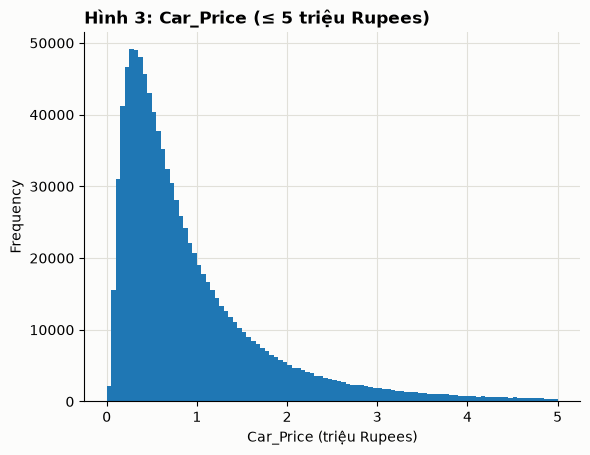

In [38]:
print("Skew Car_Price:", round(df_clean["Car_Price"].skew(), 2))
print("Tỉ lệ xe <= 5 triệu:", round((df_clean["Car_Price"] <= 5_000_000).mean() * 100, 2), "%")

(df_clean["Car_Price"] / 1e6).plot(kind="hist", bins=100, range=(0, 5))
plt.title("Hình 3: Car_Price (≤ 5 triệu Rupees)")
plt.xlabel("Car_Price (triệu Rupees)")
plt.show()

- Hình 3: 1 đỉnh duy nhất ở khoảng 0.25–0.3M, sau đó giảm dần thành đuôi dài bên phải; skew 4.55. 98.66% xe ≤ 5M nên hình chỉ vẽ tới 5M.
- Không có cột nào cao bất thường (không có giá sàn), không thấy 2 nhóm giá tách nhau.

**To do:** lệch phải mạnh → xem trên thang log.

Skew log(Car_Price): -0.0


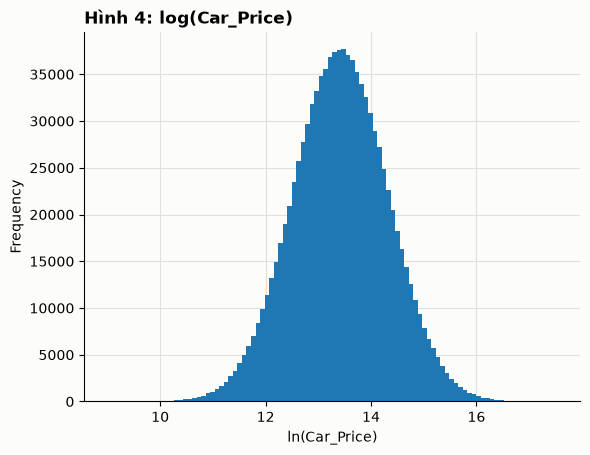

In [39]:
print("Skew log(Car_Price):", round(np.log(df_clean["Car_Price"]).skew(), 2))

np.log(df_clean["Car_Price"]).plot(kind="hist", bins=100)
plt.title("Hình 4: log(Car_Price)")
plt.xlabel("ln(Car_Price)")
plt.show()

- Hình 4: log(Car_Price) có dạng hình chuông cân đối, 1 đỉnh, skew ≈ 0 → giá xấp xỉ phân phối log-normal: lệch phải ở thang gốc, cân đối ở thang log.

In [40]:
print("Bảng 4 – Mean vs median của Car_Price (Rupees)")
for name, d in [("Toàn bộ", df_clean),
                ("Luxury", df_clean[df_clean["Segment"] == "Luxury"]),
                ("Non-luxury", df_clean[df_clean["Segment"] == "Non-luxury"])]:
    print(name, "| mean:", round(d["Car_Price"].mean()), "| median:", round(d["Car_Price"].median()),
          "| mean/median:", round(d["Car_Price"].mean() / d["Car_Price"].median(), 3))

Bảng 4 – Mean vs median của Car_Price (Rupees)


Toàn bộ | mean: 1013854 | median: 672242 | mean/median: 1.508
Luxury | mean: 1014182 | median: 670974 | mean/median: 1.512
Non-luxury | mean: 1013756 | median: 672576 | mean/median: 1.507


**Mean vs median – Bảng 4**
- Toàn bộ: mean 1,013,854 > median 672,242 (mean/median = 1.508) → phân phối Car_Price lệch phải: đa số xe có giá vừa phải, một số ít xe rất đắt (tới ~41.4M) kéo mean lên (Hình 3).
- Tỉ lệ mean/median gần như bằng nhau trong từng segment (Luxury 1.512, Non-luxury 1.507) → độ lệch là hình dạng chung của phân phối giá, không phải do trộn 2 segment.
- → Nên báo cáo **median** cho khách hàng: đó là giá của "chiếc xe điển hình"; mean cao hơn median ~51% vì bị kéo bởi số ít xe cực đắt.

**To do:** các xe giá rất cao có phải outlier cần xử lý không.

Q1: 365597 | Q3: 1239294 | Ngưỡng outlier trên: 2549839
Số xe > ngưỡng: 70605 | 7.1 %
% Luxury trong nhóm > ngưỡng: 23.2
|z| > 3: 18570


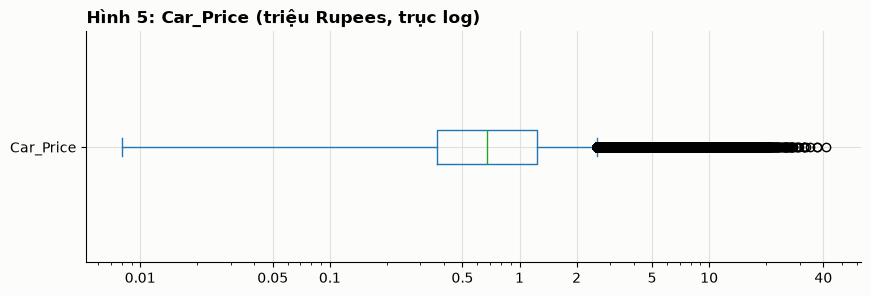

In [41]:
q1, q3 = df_clean["Car_Price"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
print("Q1:", round(q1), "| Q3:", round(q3), "| Ngưỡng outlier trên:", round(upper))
print("Số xe > ngưỡng:", (df_clean["Car_Price"] > upper).sum(), "|", round((df_clean["Car_Price"] > upper).mean() * 100, 1), "%")
print("% Luxury trong nhóm > ngưỡng:", round((df_clean.loc[df_clean["Car_Price"] > upper, "Segment"] == "Luxury").mean() * 100, 1))
print("|z| > 3:", ((df_clean["Car_Price"] - df_clean["Car_Price"].mean()) / df_clean["Car_Price"].std()).abs().gt(3).sum())

(df_clean["Car_Price"] / 1e6).plot(kind="box", vert=False, logx=True, figsize=(10, 3))
plt.xticks([0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 40], ["0.01", "0.05", "0.1", "0.5", "1", "2", "5", "10", "40"])
plt.title("Hình 5: Car_Price (triệu Rupees, trục log)")
plt.show()

**Outlier của Car_Price (Hình 5)**
- 50% xe giữa có giá 0.37M–1.24M; ngưỡng outlier trên (Q3 + 1.5 IQR) ≈ 2.55M.
- 70,605 xe (7.1%) vượt ngưỡng IQR; theo z-score (|z| > 3) chỉ 18,570 xe → IQR đánh dấu nhiều hơn vì phân phối lệch phải.
- Trong nhóm vượt ngưỡng, Luxury chiếm 23.2% ≈ tỉ lệ Luxury trong mẫu (23.1%) → outlier không tập trung ở segment nào.
- Trên trục log (Hình 5) các điểm outlier nối liền với hộp, không tách thành cụm → không thấy dấu hiệu lỗi rõ ràng; chưa có bằng chứng đủ để coi chúng là lỗi (hình chuông của log(Car_Price) ở Hình 4 chỉ cho thấy đuôi nối liền, không chứng minh mọi giá đều đúng).
- → Giữ lại; báo cáo median để không bị ảnh hưởng. Kiểm tra độ nhạy ở cuối notebook.

**Tiếp theo:** xem phân phối các biến còn lại sau làm sạch.

In [42]:
df_clean[num_cols].skew().round(2)

Car_Price           4.55
Registration_Age   -0.00
Kms_Driven          1.84
Engine_CC           0.08
Horsepower          0.05
Mileage_kmpl        0.00
Accidents           1.83
dtype: float64

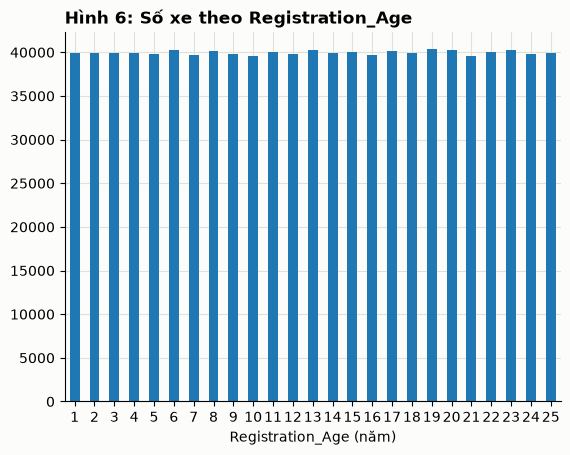

In [43]:
df_clean["Registration_Age"].value_counts().sort_index().plot(kind="bar", rot=0)
plt.title("Hình 6: Số xe theo Registration_Age")
plt.xlabel("Registration_Age (năm)")
plt.show()

**Phân phối các biến khác (df_clean)**
- Registration_Age (Hình 6): phân bố đều từ 1–25 năm (~40k xe mỗi tuổi), skew 0 → mẫu được lấy chia đều theo tuổi, không theo tỉ lệ tự nhiên.
- Kms_Driven: sau khi loại > 1M vẫn lệch phải (skew 1.84; trước khi loại: xem Hình 2).
- Engine_CC, Horsepower, Mileage_kmpl: skew ≈ 0 (0.08 / 0.05 / 0.00) → khớp với dạng gần như đều trong 1 khoảng ở Hình 1a–1c.
- Accidents: lệch phải (skew 1.83), median = 0 → đa số xe không có tai nạn.

In [44]:
for col in ["Fuel_Type", "Transmission", "Owner_Type", "Segment"]:
    print(df_clean[col].value_counts(normalize=True).mul(100).round(1))
    print("-" * 30)

Fuel_Type
Petrol      41.2
Diesel      27.7
CNG          9.0
Unknown      7.8
Electric     7.5
Hybrid       6.6
Name: proportion, dtype: float64
------------------------------
Transmission
Manual       59.8
Automatic    32.2
Unknown       8.0
Name: proportion, dtype: float64
------------------------------
Owner_Type
First      59.9
Second     25.0
Third      10.0
Fourth+     5.0
Name: proportion, dtype: float64
------------------------------


Segment
Non-luxury    76.9
Luxury        23.1
Name: proportion, dtype: float64
------------------------------


- Fuel_Type: Petrol 41.2%, Diesel 27.7%, CNG 9.0%, Unknown 7.8%, Electric 7.5%, Hybrid 6.6%.
- Transmission: Manual 59.8%, Automatic 32.2%, Unknown 8.0%. Owner_Type: First 59.9% → Second 25.0% → Third 10.0% → Fourth+ 5.0%.
- Segment: Non-luxury 76.9%, Luxury 23.1% (≈ 3/13 hãng, vì mỗi hãng có số xe gần bằng nhau).
- Mọi nhóm đều ≥ 5% → không có nhóm quá nhỏ.

**Tiếp theo:** xem biến nào liên quan tới Car_Price (correlation).

In [45]:
corr_cols = ["Registration_Age", "Kms_Driven", "Engine_CC", "Horsepower", "Mileage_kmpl",
             "Accidents", "Service_History", "Insurance_Valid", "Tax_Paid", "Seats", "Number_of_Doors"]
print("Bảng 5 – Correlation giữa các biến và Car_Price")
pd.DataFrame({
    "Pearson": df_clean[corr_cols].corrwith(df_clean["Car_Price"]),
    "Spearman": df_clean[corr_cols].corrwith(df_clean["Car_Price"], method="spearman"),
}).round(3)

Bảng 5 – Correlation giữa các biến và Car_Price


,Pearson,Spearman
Registration_Age,-0.000,-0.001
Kms_Driven,-0.051,-0.068
Engine_CC,0.029,0.035
Horsepower,0.035,0.042
Mileage_kmpl,-0.001,0.000
Accidents,-0.000,0.000
Service_History,0.001,0.000
Insurance_Valid,0.002,0.003
Tax_Paid,-0.000,-0.002
Seats,0.002,0.002


**Correlation với Car_Price (Bảng 5)**
- Mọi correlation đều rất yếu (|r| < 0.07). Mạnh nhất là Kms_Driven (Pearson -0.051 / Spearman -0.068), sau đó Horsepower (0.035 / 0.042) và Engine_CC (0.029 / 0.035).
- Registration_Age ≈ 0 (-0.000 / -0.001) → không thấy quan hệ tuyến tính / đơn điệu giữa giá và tuổi xe.
- Mileage, Accidents, Service_History, Insurance, Tax, Seats, Doors: ≈ 0 (|r| ≤ 0.003).
- Engine_CC và Horsepower có correlation với giá gần giống nhau → có thể 2 biến này liên quan với nhau.

**To do:** xem correlation giữa các biến với nhau (multicollinearity).

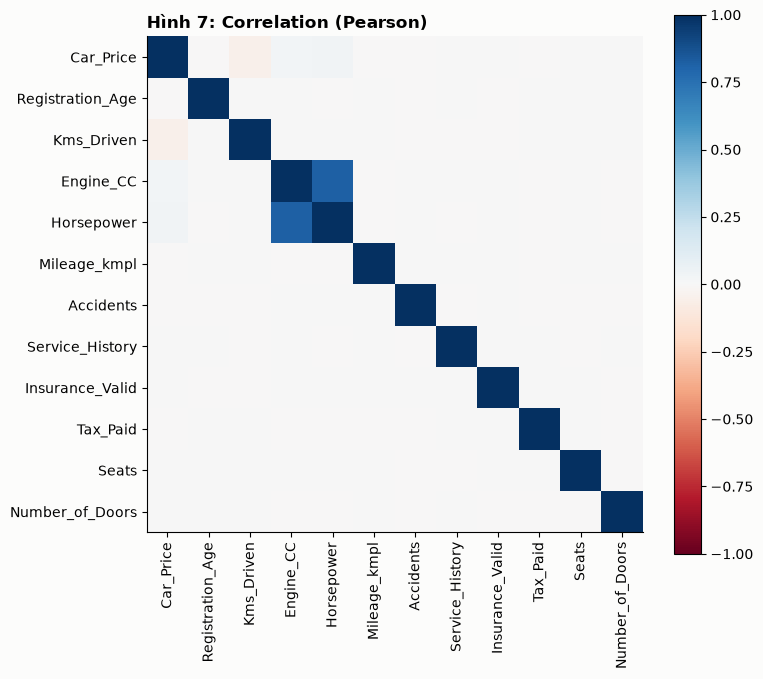

Engine_CC  Horsepower    0.815
dtype: float64


In [46]:
corr = df_clean[["Car_Price"] + corr_cols].corr()
plt.figure(figsize=(8, 7))
plt.imshow(corr, cmap="RdBu", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.grid(False)
plt.title("Hình 7: Correlation (Pearson)")
plt.show()

# các cặp biến (không tính Car_Price) có |r| > 0.1
pairs = corr.drop(index="Car_Price", columns="Car_Price").stack()
pairs = pairs[(pairs.index.get_level_values(0) < pairs.index.get_level_values(1)) & (pairs.abs() > 0.1)]
print(pairs.round(3))

- Hình 7: chỉ có 1 cặp biến tương quan mạnh: Engine_CC – Horsepower 0.815. Mọi cặp còn lại |r| ≤ 0.1, kể cả Registration_Age – Kms_Driven.
- → Multicollinearity: Engine_CC và Horsepower mang thông tin gần giống nhau, chỉ nên dùng 1 trong 2. (Year không dùng vì trùng Registration_Age.)

**Tiếp theo:** giá theo tuổi xe và Kms_Driven, bằng scatter.

Số điểm > 5 triệu (không hiện trên hình): 61


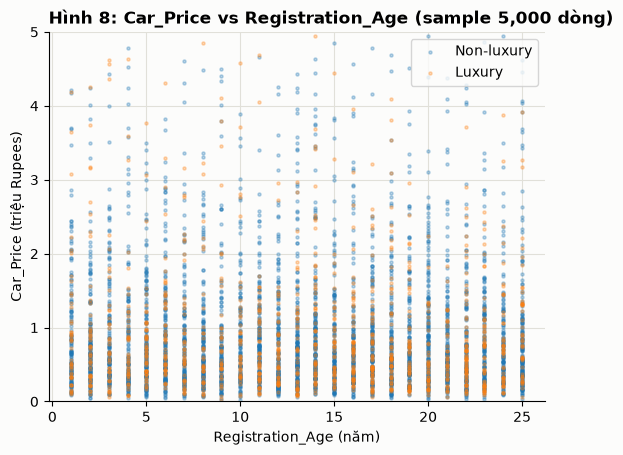

In [47]:
sample = df_clean.sample(5000, random_state=42)
print("Số điểm > 5 triệu (không hiện trên hình):", (sample["Car_Price"] > 5e6).sum())

for seg, color in [("Non-luxury", "tab:blue"), ("Luxury", "tab:orange")]:
    s = sample[sample["Segment"] == seg]
    plt.scatter(s["Registration_Age"], s["Car_Price"] / 1e6, s=5, alpha=0.3, color=color, label=seg)
plt.ylim(0, 5)
plt.title("Hình 8: Car_Price vs Registration_Age (sample 5,000 dòng)")
plt.xlabel("Registration_Age (năm)")
plt.ylabel("Car_Price (triệu Rupees)")
plt.legend()
plt.show()

- Vẽ ~1 triệu điểm thì không đọc được → scatter trên sample ngẫu nhiên 5,000 dòng (random_state=42). Trục y cắt ở 5 triệu Rupees (ẩn 61 điểm, ~1.2%, khớp với 98.66% xe ≤ 5M ở Hình 3).
- Hình 8: ở mọi tuổi xe, giá trải từ gần 0 tới 5M như nhau, dày nhất ở dưới 1M; 2 segment chồng lên nhau → không thấy xu hướng tăng hay giảm theo tuổi.
- Scatter khó thấy mức giá "điển hình" → cần thêm median theo tuổi, tính trên toàn bộ df_clean (dùng median vì giá lệch phải, Bảng 4).

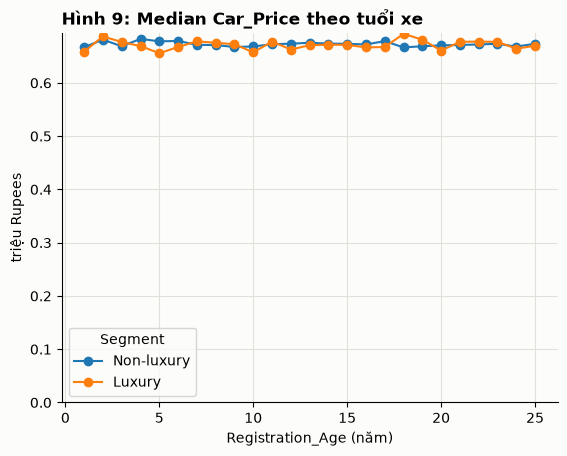

Bảng 6 – Median Car_Price theo tuổi xe (Rupees)


Segment,Non-luxury,Luxury
Registration_Age,,
1,667023.0,658760.0
5,677894.0,655687.0
10,668287.0,657262.0
15,673278.0,671337.0
20,670353.0,660626.0
25,673392.0,669550.0


In [48]:
age_price = df_clean.groupby(["Registration_Age", "Segment"])["Car_Price"].median().unstack()
age_price = age_price[["Non-luxury", "Luxury"]]
(age_price / 1e6).plot(marker="o")
plt.ylim(bottom=0)
plt.title("Hình 9: Median Car_Price theo tuổi xe")
plt.xlabel("Registration_Age (năm)")
plt.ylabel("triệu Rupees")
plt.show()

print("Bảng 6 – Median Car_Price theo tuổi xe (Rupees)")
age_price.loc[[1, 5, 10, 15, 20, 25]].round()

- Hình 9, Bảng 6: median giá gần như nằm ngang ở mọi tuổi, trong khoảng ~0.65–0.69M, ở cả 2 segment (vd Non-luxury 667k ở tuổi 1 và 673k ở tuổi 25; Luxury 659k và 670k). Chênh lệch giữa các tuổi chỉ vài %, không theo chiều nào.
- → Không thấy quan hệ đơn biến rõ giữa giá và tuổi xe; khớp với correlation ≈ 0 (Bảng 5).

**To do:** làm tương tự với Kms_Driven.

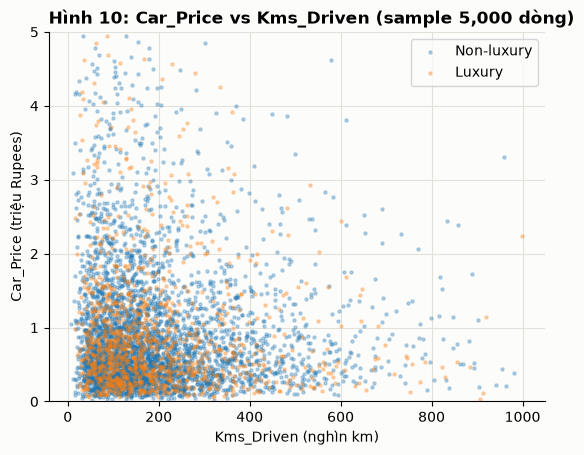

In [49]:
for seg, color in [("Non-luxury", "tab:blue"), ("Luxury", "tab:orange")]:
    s = sample[sample["Segment"] == seg]
    plt.scatter(s["Kms_Driven"] / 1000, s["Car_Price"] / 1e6, s=5, alpha=0.3, color=color, label=seg)
plt.ylim(0, 5)
plt.title("Hình 10: Car_Price vs Kms_Driven (sample 5,000 dòng)")
plt.xlabel("Kms_Driven (nghìn km)")
plt.ylabel("Car_Price (triệu Rupees)")
plt.legend()
plt.show()

- Hình 10: phần lớn xe chạy < 400k km; càng nhiều km thì càng thưa điểm và ít điểm giá cao → nhưng có thể chỉ vì ở vùng km cao có ít xe hơn, cần xem median theo nhóm km. 2 segment chồng lên nhau.

Số xe ít nhất trong 1 nhóm km: {'Non-luxury': 1044, 'Luxury': 286}


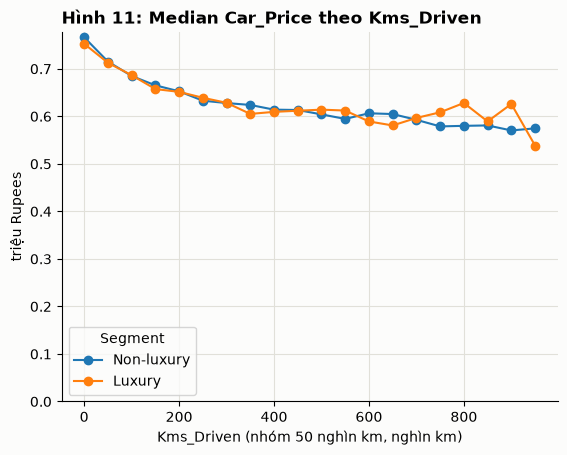

Bảng 7 – Số xe (n) và median Car_Price (Rupees) theo nhóm Kms_Driven × Segment


Segment,n Non-luxury,n Luxury,median Non-luxury,median Luxury
Kms_Driven,,,,
0.0,51947,15577,766271.0,752689.0
50.0,167104,50483,715349.0,712642.0
100.0,157935,47519,684904.0,686597.0
150.0,116618,34753,665248.0,657377.0
200.0,80653,23930,652661.0,651487.0
250.0,55464,16802,632926.0,639077.0
300.0,38646,11758,627944.0,628471.0
350.0,27071,8128,623940.0,605100.0
400.0,19154,5727,614075.0,609390.0


In [50]:
kms_band = df_clean["Kms_Driven"] // 50_000 * 50
counts = pd.crosstab(kms_band, df_clean["Segment"])[["Non-luxury", "Luxury"]]
print("Số xe ít nhất trong 1 nhóm km:", counts.min().to_dict())

kms_price = df_clean.groupby([kms_band, "Segment"])["Car_Price"].median().unstack()
kms_price = kms_price[["Non-luxury", "Luxury"]]
(kms_price / 1e6).plot(marker="o")
plt.ylim(bottom=0)
plt.title("Hình 11: Median Car_Price theo Kms_Driven")
plt.xlabel("Kms_Driven (nhóm 50 nghìn km, nghìn km)")
plt.ylabel("triệu Rupees")
plt.show()

print("Bảng 7 – Số xe (n) và median Car_Price (Rupees) theo nhóm Kms_Driven × Segment")
pd.concat([counts.add_prefix("n "), kms_price.round().add_prefix("median ")], axis=1)

**Giá theo tuổi xe và Kms_Driven – Hình 8–11, Bảng 6–7**
- Nhóm Kms 50k km. Bảng 7 có số xe của từng nhóm km × Segment: dưới 600k km mỗi nhóm có ≥ 7,582 xe Non-luxury và ≥ 2,291 xe Luxury; từ 600k km trở lên số xe giảm dần, nhóm cuối (950k–1M km) chỉ còn 1,044 Non-luxury và 286 Luxury.
- Trong khoảng có nhiều xe (< 600k km), median giá có xu hướng thấp hơn ở nhóm km cao ở cả 2 segment: Non-luxury 766k (< 50k km) → 628k (300k–350k) → 595k (550k–600k), Luxury 753k → 628k → 612k, tức thấp hơn ~19–22%. Phần lớn chênh lệch nằm ở 300k km đầu.
- Từ 600k km trở lên: Non-luxury vẫn thấp dần (606k → 575k), còn đường Luxury dao động mạnh (539k–628k, không theo chiều nào) vì ít xe → không kết luận về xu hướng của Luxury ở đuôi.
- 2 segment gần như trùng nhau → mối liên hệ giá – km quan sát được giống nhau ở cả 2 segment.
- → Giá có association âm, yếu với Kms_Driven (Spearman -0.068, Bảng 5): trong mỗi nhóm km, giá vẫn trải rất rộng (Hình 10).
- So với tuổi xe: với tuổi xe không thấy quan hệ đơn biến rõ (Hình 9), với Kms thì có association âm yếu. Đây là so sánh từng biến riêng lẻ, chưa tách được tác động của các biến khác.

**Tiếp theo:** giá có khác nhau giữa 2 segment không (Bảng 3 cho thấy gần như không) → kiểm tra theo từng Brand.

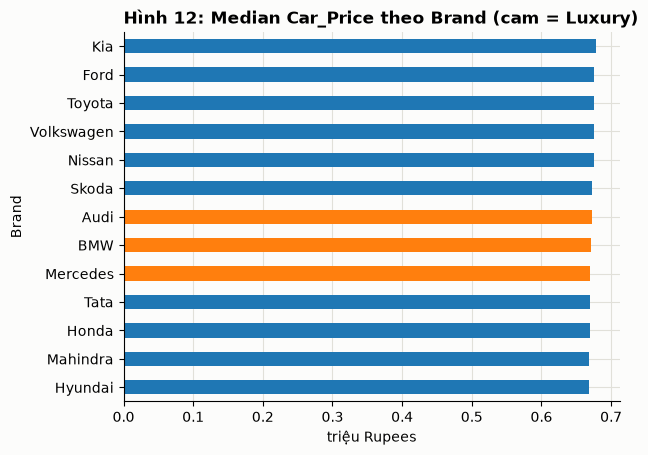

Bảng 8 – Median Car_Price theo Brand (Rupees)


Brand
Kia           678198.0
Ford          675604.0
Toyota        675335.0
Volkswagen    674948.0
Nissan        674767.0
Skoda         672436.0
Audi          672050.0
BMW           670809.0
Mercedes      670103.0
Tata          669681.0
Honda         669398.0
Mahindra      668473.0
Hyundai       667823.0
Name: Car_Price, dtype: float64

In [51]:
lux = ["Audi", "BMW", "Mercedes"]
brand_price = df_clean.groupby("Brand")["Car_Price"].median().sort_values()
colors = ["tab:orange" if b in lux else "tab:blue" for b in brand_price.index]
(brand_price / 1e6).plot(kind="barh", color=colors)
plt.title("Hình 12: Median Car_Price theo Brand (cam = Luxury)")
plt.xlabel("triệu Rupees")
plt.show()

print("Bảng 8 – Median Car_Price theo Brand (Rupees)")
brand_price.round().sort_values(ascending=False)

- Hình 12, Bảng 8: median của cả 13 hãng nằm trong 668k–678k (chênh ~1.6%); 3 hãng Luxury (Audi 672k, BMW 671k, Mercedes 670k) nằm lẫn giữa các hãng Non-luxury.
- → Không hãng nào đắt hơn rõ rệt. Median bằng nhau chưa chắc toàn bộ phân phối giống nhau → so sánh cả phân phối giá của 2 segment.

In [52]:
print("Bảng 9 – Car_Price (Rupees) theo Segment")
df_clean.groupby("Segment")["Car_Price"].describe().round()

Bảng 9 – Car_Price (Rupees) theo Segment


,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
Luxury,230749.0,1014182.0,1140297.0,13441.0,365366.0,670974.0,1238096.0,41442181.0
Non-luxury,768145.0,1013756.0,1140446.0,7987.0,365673.0,672576.0,1239596.0,37227010.0


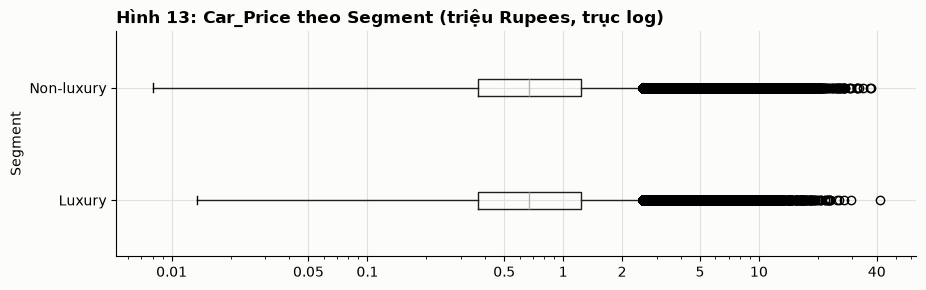

In [53]:
df_clean.boxplot(column="Car_Price", by="Segment", vert=False, figsize=(10, 3))
plt.xscale("log")
plt.xticks([1e4, 5e4, 1e5, 5e5, 1e6, 2e6, 5e6, 1e7, 4e7], ["0.01", "0.05", "0.1", "0.5", "1", "2", "5", "10", "40"])
plt.suptitle("")
plt.title("Hình 13: Car_Price theo Segment (triệu Rupees, trục log)")
plt.show()

**Ảnh hưởng của Segment – Bảng 8–9, Hình 12–13**
- Bảng 9: Luxury vs Non-luxury gần như trùng khít: Q1 365,366 vs 365,673; median 670,974 vs 672,576; Q3 1,238,096 vs 1,239,596; mean và SD chênh < 0.1%.
- Hình 13: 2 hộp nằm chồng lên nhau, đuôi phải giống nhau (max 41.4M vs 37.2M chỉ là vài xe lẻ).
- → Phân phối giá quan sát được của 2 segment gần tương đồng: median Luxury / Non-luxury = 0.998; median giữa các hãng cũng gần như bằng nhau (Hình 12). Đây là so sánh mô tả, chưa kiểm soát các biến khác.

**To do:** kiểm tra các biến chữ / rời rạc còn lại.

In [54]:
for col in ["Model", "Fuel_Type", "Transmission", "Owner_Type", "Color", "City", "Accidents",
            "Service_History", "Insurance_Valid", "Tax_Paid", "Seats", "Number_of_Doors"]:
    m = df_clean.groupby(col)["Car_Price"].median()
    print(col, ":", round(m.min()), "->", round(m.max()), "| max/min =", round(m.max() / m.min(), 3))

Model : 659510 -> 681010 | max/min = 1.033
Fuel_Type : 668450 -> 674475 | max/min = 1.009
Transmission : 670839 -> 673021 | max/min = 1.003


Owner_Type : 668880 -> 674085 | max/min = 1.008
Color : 667598 -> 675897 | max/min = 1.012
City : 668484 -> 674927 | max/min = 1.01
Accidents : 622499 -> 1275716 | max/min = 2.049
Service_History : 672028 -> 672936 | max/min = 1.001
Insurance_Valid : 666470 -> 673344 | max/min = 1.01
Tax_Paid : 671621 -> 677769 | max/min = 1.009
Seats : 668088 -> 674428 | max/min = 1.009
Number_of_Doors : 671677 -> 673960 | max/min = 1.003


- Model, Fuel_Type, Transmission, Owner_Type, Color, City, Service_History, Insurance_Valid, Tax_Paid, Seats, Number_of_Doors: median giữa các nhóm chênh ≤ 3.3% (Model 1.033, các biến khác ≤ 1.012) → không thấy chênh lệch giá đáng kể giữa các nhóm.
- Accidents: max/min = 2.05 → khác hẳn các biến còn lại, cần xem chi tiết.

In [55]:
print("Bảng 10 – Số xe và median Car_Price (Rupees) theo Accidents")
df_clean.groupby("Accidents")["Car_Price"].agg(["count", "median"]).round()

Bảng 10 – Số xe và median Car_Price (Rupees) theo Accidents


,count,median
Accidents,,
0,740433,671995.0
1,221613,673302.0
2,33235,670104.0
3,3375,679503.0
4,222,622499.0
5,16,1275716.0


- Bảng 10: Accidents 0–3 vụ có median 670k–680k, không có xu hướng. Chỉ 2 nhóm cuối khác: 4 vụ (222 xe) 622k và 5 vụ (16 xe) 1.28M → quá ít xe nên median dao động mạnh (giá trải rất rộng, Hình 3); 2 nhóm này ngược chiều nhau → không phải xu hướng.
- → Không thấy quan hệ rõ giữa số tai nạn và giá (khớp với correlation ≈ 0, Bảng 5).

**Tiếp theo:** kiểm tra kết quả có thay đổi không nếu xử lý dữ liệu theo cách khác (Bảng 2).

In [56]:
# các cách xử lý khác để so sánh
keep_kms = df.copy()
keep_kms["Segment"] = keep_kms["Brand"].str.strip().isin(lux).map({True: "Luxury", False: "Non-luxury"})

q1, q3 = df_clean["Car_Price"].quantile([0.25, 0.75])
price_upper = q3 + 1.5 * (q3 - q1)

print("Bảng 11 – Độ nhạy của kết quả theo cách xử lý dữ liệu")
for name, d in [("Đang dùng: loại Kms > 1M", df_clean),
                ("Giữ cả Kms > 1M", keep_kms),
                ("Đang dùng + xoá dòng trùng ở 15 cột", df_clean.drop_duplicates(subset=other_cols)),
                ("Đang dùng + bỏ outlier Car_Price (IQR)", df_clean[df_clean["Car_Price"] <= price_upper])]:
    med_lux = d.loc[d["Segment"] == "Luxury", "Car_Price"].median()
    med_non = d.loc[d["Segment"] == "Non-luxury", "Car_Price"].median()
    print(name)
    print("   số dòng:", len(d), "| median Luxury:", round(med_lux), "| median Non-luxury:", round(med_non),
          "| Luxury / Non-luxury:", round(med_lux / med_non, 3))
    print("   Spearman(giá, km):", round(d["Car_Price"].corr(d["Kms_Driven"], method="spearman"), 3),
          "| Spearman(giá, tuổi):", round(d["Car_Price"].corr(d["Registration_Age"], method="spearman"), 3))

Bảng 11 – Độ nhạy của kết quả theo cách xử lý dữ liệu


Đang dùng: loại Kms > 1M
   số dòng: 998894 | median Luxury: 670974 | median Non-luxury: 672576 | Luxury / Non-luxury: 0.998


   Spearman(giá, km): -0.068 | Spearman(giá, tuổi): -0.001
Giữ cả Kms > 1M
   số dòng: 1005000 | median Luxury: 670026 | median Non-luxury: 671791 | Luxury / Non-luxury: 0.997


   Spearman(giá, km): -0.07 | Spearman(giá, tuổi): -0.001
Đang dùng + xoá dòng trùng ở 15 cột
   số dòng: 969629 | median Luxury: 671091 | median Non-luxury: 672771 | Luxury / Non-luxury: 0.998


   Spearman(giá, km): -0.068 | Spearman(giá, tuổi): -0.0
Đang dùng + bỏ outlier Car_Price (IQR)
   số dòng: 928289 | median Luxury: 619762 | median Non-luxury: 620661 | Luxury / Non-luxury: 0.999


   Spearman(giá, km): -0.06 | Spearman(giá, tuổi): -0.001


In [57]:
print("Bảng 12 – Độ nhạy khi đổi giá trị ngoài khoảng chính của Mileage / Engine / HP thành NaN")
for col, (lo, hi) in main_range.items():
    s = df_clean[col]
    trimmed = s.where(s.between(lo, hi))
    print(col, "| số ô bị đổi:", (s.notna() & trimmed.isna()).sum())
    for name, x in [("   giữ (đang dùng)", s), ("   đổi thành NaN  ", trimmed)]:
        print(name, "| mean:", round(x.mean(), 2), "| median:", round(x.median(), 2), "| SD:", round(x.std(), 2),
              "| min:", round(x.min(), 2), "| max:", round(x.max(), 2),
              "| Spearman với giá:", round(x.corr(df_clean["Car_Price"], method="spearman"), 3))

Bảng 12 – Độ nhạy khi đổi giá trị ngoài khoảng chính của Mileage / Engine / HP thành NaN
Mileage_kmpl | số ô bị đổi: 109
   giữ (đang dùng) | mean: 18.0 | median: 17.99 | SD: 4.17 | min: 0.07 | max: 46.84 | Spearman với giá: 0.0


   đổi thành NaN   | mean: 18.0 | median: 17.99 | SD: 4.17 | min: 11.01 | max: 25.03 | Spearman với giá: 0.0
Engine_CC | số ô bị đổi: 252
   giữ (đang dùng) | mean: 1505.85 | median: 1494.24 | SD: 408.49 | min: 10.77 | max: 3917.06 | Spearman với giá: 0.035


   đổi thành NaN   | mean: 1505.72 | median: 1494.15 | SD: 408.16 | min: 860.3 | max: 2208.82 | Spearman với giá: 0.035
Horsepower | số ô bị đổi: 152
   giữ (đang dùng) | mean: 120.53 | median: 119.9 | SD: 38.69 | min: 6.62 | max: 432.61 | Spearman với giá: 0.042


   đổi thành NaN   | mean: 120.52 | median: 119.9 | SD: 38.67 | min: 57.15 | max: 186.97 | Spearman với giá: 0.042


- Đổi các giá trị ngoài khoảng chính (kể cả giá trị dương rất nhỏ) thành NaN: Mileage_kmpl 109 ô, Engine_CC 252, Horsepower 152 (trên df_clean).
- Mean, median, SD đổi < 0.1% (vd Engine_CC mean 1,505.85 → 1,505.72; SD 408.49 → 408.16), Spearman với giá không đổi (0.000 / 0.035 / 0.042).
- Chỉ Min / Max ở Bảng 3a–3c thay đổi (vd Mileage min 0.07 → 11.01 km/l) → giữ các giá trị này không làm đổi mô tả trung tâm hay association với giá, nhưng Min / Max cần đọc kèm ghi chú.

**Độ không chắc chắn (uncertainties) – Bảng 1, Bảng 11**
- Cách thu thập / ghi nhận dữ liệu không rõ: Mileage / Engine / HP dồn ở 2 mép khoảng (Hình 1a–1c) → giá trị ở mép có thể đã bị chặn; Kms không tăng theo tuổi xe (median ~153k km ở mọi tuổi) → độ tin cậy của Kms thấp.
- Đơn vị giả định (Bảng 1): Horsepower (hp), Kms_Driven (km), Registration_Age (năm), ý nghĩa giá trị 1 của các biến 0/1; Year + Registration_Age = 2025 ở mọi dòng nhưng không biết 2025 là năm thu thập hay năm đăng tin (không có ngày đăng tin).
- Giá trị 0 → NaN (41 ô): không biết giá trị thật, nhưng rất ít. Các giá trị lẻ khác 0 nằm ngoài khoảng chính (< 0.03% mỗi cột) vẫn giữ (gồm cả giá trị dương rất nhỏ như 0.07 km/l, 10.77 cc, 6.62 hp) vì không có ranh giới rõ giữa sai và hiếm; Bảng 12: đổi thành NaN gần như không làm đổi mean / median / SD / Spearman.
- 'Unknown' (28.2% dòng): không biết nhãn thật; giữ như 1 nhóm riêng. So sánh gộp không thấy khác biệt lớn về median giá, nhưng cơ chế thiếu nhãn chưa rõ và chưa kiểm tra trong từng nhóm nhỏ.
- Dòng trùng ở 15 cột: không biết là listing lặp hay 2 xe khác nhau. Bảng 11: nếu xoá (29,265 dòng sau khi chuẩn hoá nhãn), median chỉ đổi < 0.1% (Luxury 670,974 → 671,091).
- Ngưỡng Kms > 1M lấy theo Guide, dữ liệu không có ranh giới rõ ở mốc này (Hình 2). Bảng 11: nếu giữ lại 6,106 xe này, median Luxury 670,974 → 670,026, Spearman(giá, km) -0.068 → -0.070 → gần như không đổi.
- Outlier Car_Price: nếu bỏ 70,605 xe vượt ngưỡng IQR, median cả 2 segment giảm ~7.7% (Luxury 670,974 → 619,762) nhưng tỉ lệ Luxury / Non-luxury vẫn ~1.00 → mức giá điển hình nhạy với cách xử lý outlier, còn so sánh tương đối giữa 2 segment thì ổn định.
- Nhóm nhỏ (Accidents 4–5 vụ; Luxury ở vùng Kms cao) → median dao động mạnh, không dùng để kết luận.
- Mode của biến liên tục không ổn định (Bảng 3a–3c) → không dùng mode để mô tả giá / km.

**Tổng kết EDA**

**Phát hiện chính**
1. Car_Price lệch phải: mean 1,013,854 > median 672,242 (mean/median 1.51, skew 4.55; Bảng 4, Hình 3, 5) → báo cáo median cho khách hàng. log(Car_Price) gần như đối xứng (Hình 4).
2. Phân phối giá quan sát được của 2 segment gần tương đồng: median Luxury 670,974 vs Non-luxury 672,576 (tỉ lệ 0.998); 13 hãng đều ở 668k–678k (Bảng 3a–3c, 8–9, Hình 12–13).
3. Không thấy quan hệ đơn biến rõ giữa giá và tuổi xe: Spearman -0.001; median ~0.65–0.69M ở mọi tuổi (Bảng 5–6, Hình 8–9).
4. Median giá có xu hướng thấp hơn ở nhóm km cao (association âm, yếu; Spearman -0.068): trong khoảng < 600k km, Non-luxury 766k → 595k, Luxury 753k → 612k; ở vùng > 600k km nhóm Luxury thưa (286–1,722 xe) nên median dao động (Bảng 7, Hình 10–11).
5. Engine_CC và Horsepower có correlation dương rất yếu với giá (Spearman 0.035 / 0.042) và tương quan mạnh với nhau (0.815) → multicollinearity (Hình 7).
6. Các biến còn lại (Model, Fuel, Transmission, Owner, Color, City, Accidents, Service_History, Insurance, Tax, Seats, Doors) không cho thấy chênh lệch giá đáng kể giữa các nhóm (median chênh ≤ 3.3%, trừ nhóm Accidents rất nhỏ; Bảng 10).
7. Xử lý dữ liệu (Bảng 2): chuẩn hoá nhãn Brand, Fuel_Type; 41 giá trị 0 → NaN; loại 6,106 xe Kms > 1M (còn 998,894 dòng, 99.39%). Giữ: 'Unknown', dòng trùng ở 15 cột, outlier giá, các giá trị ngoài khoảng chính của Mileage / Engine / HP.
8. Độ nhạy (Bảng 11–12):
   - Ổn định: tỉ lệ median Luxury / Non-luxury (0.997–0.999); dấu âm của Spearman(giá, km) (-0.060 → -0.070); Spearman(giá, tuổi) ≈ 0 (-0.001 → 0.000).
   - Gần như không đổi: giữ lại Kms > 1M hoặc xoá dòng trùng ở 15 cột → median mỗi segment đổi < 0.2%; đổi giá trị ngoài khoảng chính của Mileage / Engine / HP thành NaN → mean / median / SD đổi < 0.1%, Spearman không đổi.
   - Nhạy: mức giá điển hình – bỏ outlier giá theo IQR làm median giảm ~7.6–7.7% (Luxury 670,974 → 619,762; Non-luxury 672,576 → 620,661 Rupees).

**Hạn chế**
- Mẫu được lấy chia đều theo tuổi, brand, model, city (Hình 6, số dòng mỗi nhóm gần bằng nhau) → không dùng tỉ lệ trong mẫu (vd 23.1% Luxury) để suy ra tỉ lệ ngoài thị trường.
- Kms_Driven không tăng theo tuổi xe (corr 0.0) – trái với GIẢ ĐỊNH quãng đường tích luỹ theo thời gian → kết luận về giá theo Kms cần đọc thận trọng.
- Các biến hiện có giải thích rất ít biến động của giá: mọi |correlation| < 0.07 (Bảng 5), trong cùng nhóm tuổi / km giá vẫn trải từ gần 0 tới > 5M (Hình 8, 10) → phần lớn biến động của giá không gắn với các biến có trong dữ liệu.
- 'Unknown' ở 28.2% dòng; không có ID listing → không xác định chắc được dòng trùng.
- Không có ngày đăng tin → không biết mốc 2025 (Year + Registration_Age) là năm thu thập hay đăng tin; không xem được giá thay đổi theo thời gian.
- EDA xét từng biến (hoặc từng cặp biến) → chỉ thấy mối liên quan, chưa tách được ảnh hưởng riêng của từng biến, và không cho thấy quan hệ nhân quả.

**Đề xuất cách làm tốt hơn**
- Bổ sung dữ liệu:
  - ID listing / mã xe → xác định dòng trùng và xe đăng lại.
  - Ngày đăng tin và giá bán thực tế → năm tham chiếu chính xác, xem được xu hướng giá theo thời gian.
  - Các thông tin có thể giải thích phần biến động giá còn lại (vd phiên bản, tình trạng xe) → vì các biến hiện có giải thích rất ít.
  - Số km lấy từ hồ sơ bảo dưỡng / kiểm định → đối chiếu độ tin cậy của Kms_Driven.
  - Thông tin về cách lấy mẫu (tỉ lệ thật của từng hãng, city, tuổi xe) → dùng trọng số khi khái quát ra thị trường.
- Phương pháp:
  - Dùng median và log(Car_Price) vì giá lệch phải mạnh (Bảng 4, Hình 4).
  - Phân tích nhiều biến cùng lúc (vd hồi quy) để tách ảnh hưởng riêng của Kms, tuổi xe, segment… thay vì xét từng biến.
  - Luôn kiểm tra độ nhạy của kết quả với các quyết định làm sạch (như Bảng 11).
  - Với 'Unknown': so sánh kết quả khi giữ như 1 nhóm và khi bỏ các dòng này.

**Bước tiếp theo**
- Kiểm tra quan hệ giá – km khi chia theo nhóm tuổi xe (và theo segment), để xem association có giữ nguyên khi cố định tuổi.
- Với các nhóm thưa (Luxury ở Kms > 600k km, Accidents 4–5 vụ): gộp nhóm hoặc luôn báo cáo kèm số xe trước khi so sánh.
- Xác minh ý nghĩa các đơn vị giả định (Horsepower, Kms_Driven, Registration_Age, biến 0/1), mốc 2025 và 'Unknown' với mô tả dữ liệu được cấp / tutor.